<div style="text-align: center; font-family: 'Times New Roman', Times, serif; max-width: 100%; padding: 0 20px;">
    <h1 style="margin: 0; line-height: 1.5;">CIE 2</h1>
    <h1 style="margin: 0; line-height: 1.5;">Customer Segmentation using</h1>
    <h1 style="margin: 0; line-height: 1.5;">Boltzmann Machine (RBM)</h1>
    <h3 style="margin: 10px 0 0 0; line-height: 1.5;">Online Retail II Data UCI Machine Learning</h3>
    <h3 style="margin: 0; line-height: 1.5;">Samyak Hadgekar | Roll No: TY-AIDS-A-32</h3>
    <h4 style="margin: 0; line-height: 1.5; word-wrap: break-word;">
        Github Link: 
        <a href="https://github.com/vishalhiwale/DeepLearningProjects/blob/116667079612b4dc4bd356b7aea720dc4d50eb22/Customer_Segmentaion_using_RBM.ipynb" 
           style="text-decoration: underline; word-break: break-all;">
           https://github.com/vishalhiwale/DeepLearningProjects/blob/116667079612b4dc4bd356b7aea720dc4d50eb22/Customer_Segmentaion_using_RBM.ipynb
        </a>
    </h4>
</div>


Lets import the requirement libraris for the project

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.neural_network import BernoulliRBM
from sklearn.cluster import KMeans

## Dataset Description

Dataset contains transactional data of an online retail store.  
Features of dataset include:
- Invoice
- Stock Code (Product ID)
- Description
- Quantity
- Invoice Date
- Price
- Customer ID
- Country

load the dataset using pandas

In [5]:
data = pd.read_excel("online+retail+ii\online_retail_II.xlsx", engine="openpyxl")
# Display first few rows
data.head()


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


## Data description and understanding

We will check the dataset's structure, columns, and size.

In [9]:
print("Shape: ", data.shape)
print("\nColumns: ", list(data.columns))
print("\nSize: ", data.size)


Shape:  (525461, 8)

Columns:  ['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'Price', 'Customer ID', 'Country']

Size:  4203688


Dataset contents total 525461 rows and 8 columns,  
with total size of 4203688

## Data Cleaning

In [18]:
print(f"Null values in each feature:\n{data.isna().sum()}",)
print(f"\nTotal duplicate values in the dataset: ", data.duplicated().sum())

Null values in each feature:
Invoice             0
StockCode           0
Description      2928
Quantity            0
InvoiceDate         0
Price               0
Customer ID    107927
Country             0
dtype: int64

Total duplicate values in the dataset:  6865


we can see that there total 2928 Null values in Description and 107927 Null values in Customer ID,  
and total 6865 Duplicate valeus in dataset
- remove NULL values from the Customer ID
- remove duplicated values
- remove those quanity which are less than 0

In [19]:
# Remove missing Customer ID
data = data.dropna(subset=['Customer ID'])

# Remove invalid quantities
data = data[data['Quantity'] > 0]

# Remove duplicates
data = data.drop_duplicates()

print("After cleaning:", data.shape)

After cleaning: (400947, 8)


After cleaning we have 400947 rows and 8 columns

## Data Transformation

We convert data into a Customer-Product matrix.  
We reshape the data into a Customer-Product Matrix (also called a basket matrix).

- Each row = one customer
- Each column = one product (StockCode)
- Each cell value = total quantity purchased by that customer for that product
- fill_value=0 → products not bought by a customer are filled with 0

This matrix format is required as input for the RBM model.

In [20]:
basket = data.pivot_table(
    index='Customer ID',
    columns='StockCode',
    values='Quantity',
    aggfunc='sum',
    fill_value=0
)

basket.head()

StockCode,10002,10080,10109,10120,10125,10133,10134,10135,10138,11001,...,ADJUST2,BANK CHARGES,C2,D,M,PADS,POST,SP1002,TEST001,TEST002
Customer ID,,,,,,,,,,,,,,,,,,,,,
12346.0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,45,1
12347.0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
12348.0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,1,0,0,0
12349.0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,2,0,0,0
12351.0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


## Binary Conversion  
We convert the quantity values into binary (0 or 1):

- 1 → the customer purchased this product (at least once)
- 0 → the customer did not purchase this product  

This is necessary because BernoulliRBM works with binary input data. We only care about whether a product was bought, not how many times.

In [21]:
basket[basket > 0] = 1
basket[basket == 0] = 0

## Filtering Customers

Remove customers with very few purchases to improve model learning.

In [22]:
basket = basket[basket.sum(axis=1) > 5]

We remove customers who have purchased fewer than 5 distinct products. Such customers don't have enough purchase history for the model to learn meaningful patterns from. Keeping only active customers improves the quality of segmentation and model performance.

## Feature Scaling

Normalize data using MinMaxScaler.

In [23]:
# Fix column names (VERY IMPORTANT)
basket.columns = basket.columns.astype(str)

# Now apply scaling
scaler = MinMaxScaler()
basket_scaled = scaler.fit_transform(basket)

- basket.columns.astype(str) → converts column names to strings (important to avoid errors since StockCode may be numeric)  
- MinMaxScaler() → scales all values to the range [0, 1]  
- fit_transform() → fits the scaler on the data and transforms it in one step

Even though the data is already binary (0 and 1), scaling ensures compatibility with the RBM's internal computations.

## Training Boltzmann Machine (RBM)

RBM learns hidden patterns in customer purchase data.

In [24]:
rbm = BernoulliRBM(
    n_components=30,
    learning_rate=0.05,
    n_iter=20,
    random_state=0,
    verbose=True
)

rbm.fit(basket_scaled)

[BernoulliRBM] Iteration 1, pseudo-likelihood = -303.80, time = 1.13s
[BernoulliRBM] Iteration 2, pseudo-likelihood = -291.78, time = 1.49s
[BernoulliRBM] Iteration 3, pseudo-likelihood = -287.02, time = 1.37s
[BernoulliRBM] Iteration 4, pseudo-likelihood = -284.29, time = 1.29s
[BernoulliRBM] Iteration 5, pseudo-likelihood = -285.72, time = 1.27s
[BernoulliRBM] Iteration 6, pseudo-likelihood = -283.93, time = 1.29s
[BernoulliRBM] Iteration 7, pseudo-likelihood = -279.42, time = 1.35s
[BernoulliRBM] Iteration 8, pseudo-likelihood = -280.23, time = 1.27s
[BernoulliRBM] Iteration 9, pseudo-likelihood = -276.36, time = 1.27s
[BernoulliRBM] Iteration 10, pseudo-likelihood = -276.86, time = 1.17s
[BernoulliRBM] Iteration 11, pseudo-likelihood = -276.25, time = 1.18s
[BernoulliRBM] Iteration 12, pseudo-likelihood = -271.42, time = 1.22s
[BernoulliRBM] Iteration 13, pseudo-likelihood = -269.96, time = 1.18s
[BernoulliRBM] Iteration 14, pseudo-likelihood = -273.56, time = 1.22s
[BernoulliRBM] 

,n_components,30
,learning_rate,0.05
,batch_size,10
,n_iter,20
,verbose,True
,random_state,0


We train the Restricted Boltzmann Machine (RBM) on the customer purchase data.

- n_components=30 → number of hidden neurons (hidden features to learn)
- learning_rate=0.05 → controls how fast the model learns (too high = unstable, too low = slow)
- n_iter=20 → number of training epochs (passes through the data)
- random_state=0 → for reproducibility
- verbose=True → prints training progress

The RBM learns hidden relationships between products that customers tend to buy together.

## Feature Extraction

Extract hidden features learned by RBM.

In [25]:
hidden = rbm.transform(basket_scaled)

print("Hidden shape:", hidden.shape)

Hidden shape: (3974, 30)


After training, we use rbm.transform() to extract the hidden feature representation of each customer. Instead of thousands of product columns, each customer is now represented by just 30 hidden features that capture buying patterns. This compressed representation is then used for clustering.

## Customer Segmentation using KMeans  

### Finding Optimal K (Elbow Method)
using a loop to find optimal k

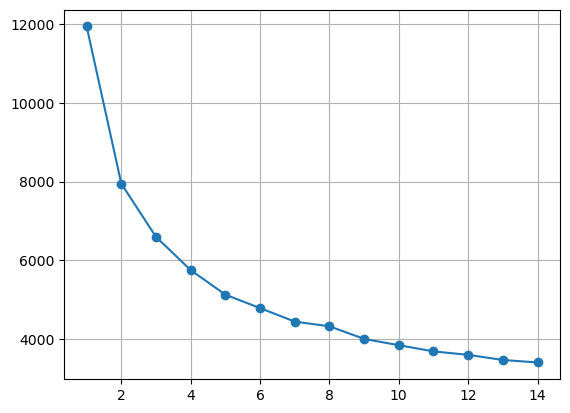

In [46]:
wcss=[]
for k in range(1, 15):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(hidden)
    wcss.append(kmeans.inertia_)

plt.plot(np.arange(1, 15), wcss, marker='o')
plt.grid(True)
plt.show()

So from graph,  
we can say that thers is no perfect elbow structe to find best value of k  
but we can suppose 6 as a best value of k

## Visualization of Customer Segments

Cluster labels k=14: [5 3 4 2 0 5 0 0 4 3]


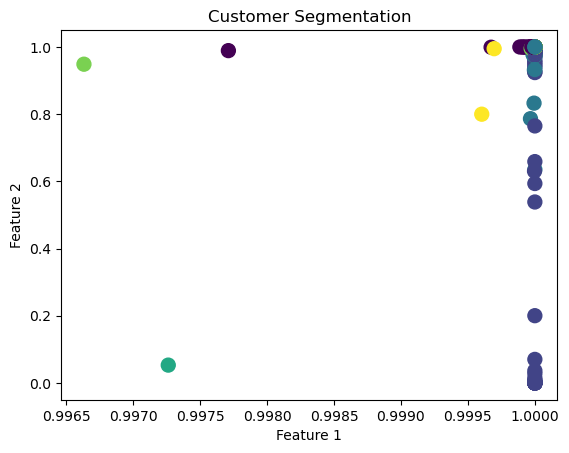

In [51]:
kmeans = KMeans(n_clusters=6, random_state=0)
clusters = kmeans.fit_predict(hidden)
print(f"Cluster labels k={k}: {clusters[:10]}")

plt.figure()
plt.scatter(hidden[:, 0], hidden[:, 1], c=clusters, s=100, marker='o', label='centroids')
plt.title("Customer Segmentation")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

## Results

After training the Restricted Boltzmann Machine and applying KMeans clustering, the following results were obtained:
- The RBM successfully compressed the high-dimensional customer-product matrix (with thousands of product columns) into just 30 meaningful hidden features per customer.
- The Elbow Method graph suggested k = 6 as a suitable number of clusters, though no sharp elbow was visible due to the sparse nature of retail data.
- KMeans successfully grouped all customers into 6 distinct segments based on their hidden feature representations.
- The scatter plot shows customers distributed across 6 color-coded clusters, indicating that the model was able to find structure in the data.
- Customers within the same cluster share similar purchasing patterns, meaning they tend to buy similar types or combinations of products.

## Observations
- **Cluster separation:** Customers with similar buying habits (e.g., bulk buyers, occasional buyers, category-specific buyers) are grouped into the same cluster, making the segments interpretable for business use.
- **Hidden feature power:** The RBM captured latent (hidden) relationships between products that are not directly visible in the raw data — for example, products that are frequently bought together get represented similarly in the hidden layer.
- **Data sparsity issue:** Since most customers buy only a small fraction of the total available products, the customer-product matrix is very sparse (mostly 0s), which makes it harder for the model to find strong patterns. This is why the elbow curve was not very sharp.
- **Filtering effect:** Removing customers with fewer than 5 purchases significantly improved the quality of the clusters, as customers with very little data do not provide enough signal for meaningful segmentation.
- **Dimensionality reduction benefit:** Reducing thousands of product features to just 30 hidden features not only made the clustering faster but also removed noise from the data, leading to more stable and meaningful clusters.

 

## Conclusion
In this experiment, we successfully implemented a customer segmentation system using a Restricted Boltzmann Machine (RBM) combined with KMeans clustering on the Online Retail II dataset.

* The RBM acted as an unsupervised feature extractor, learning hidden purchasing patterns from the binary customer-product matrix without requiring any labeled data.
* KMeans then used these compressed hidden features to group customers into 6 segments, each representing a distinct type of buyer behavior.
* This approach is far more powerful than directly clustering on raw product data, because RBM learns deep representations that capture relationships between products.
* Such segmentation has strong real-world applications in:

    * Recommendation systems — suggest products based on the customer's cluster
    * Targeted marketing — send personalized offers to each segment
    * Inventory management — stock products based on cluster buying trends